In [1]:
# Import libraries
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Load dataset, re-format date
df = pd.read_csv("../data/processed/master_dataset.csv",parse_dates=["date"])
df = df.set_index("date").sort_index()

print(df.shape)
df.head()

(2319, 8)


,open,high,low,close,volume,fear_greed,hash_rate,n_transactions
date,,,,,,,,
2020-01-01,7195.24,7255.0,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0
2020-01-02,7200.77,7212.5,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0
2020-01-03,6965.49,7405.0,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0
2020-01-04,7345.00,7404.0,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0
2020-01-05,7354.19,7495.0,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0


In [17]:
# Describe data
df.describe().round(2)

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions
count,2319.00,2319.00,2319.00,2319.00,2319.00,2319.00,2.319000e+03,2319.00
mean,48732.79,49732.30,47667.83,48764.65,70960.56,48.39,4.363244e+08,372339.94
std,31324.52,31788.31,30820.45,31319.74,85544.92,22.69,3.214656e+08,130897.31
min,4800.01,5365.42,3782.13,4800.00,2235.97,5.00,5.846100e+07,124640.00
25%,23015.52,23474.90,22558.50,23041.77,24312.38,27.00,1.549812e+08,275087.50
50%,42158.85,43079.00,41250.00,42201.13,43559.75,49.00,3.139301e+08,329938.00
75%,68004.02,69275.48,66600.06,68020.86,76342.51,70.00,6.909447e+08,447682.50
max,124658.54,126199.63,123084.00,124658.54,760705.36,95.00,1.305500e+09,927010.00


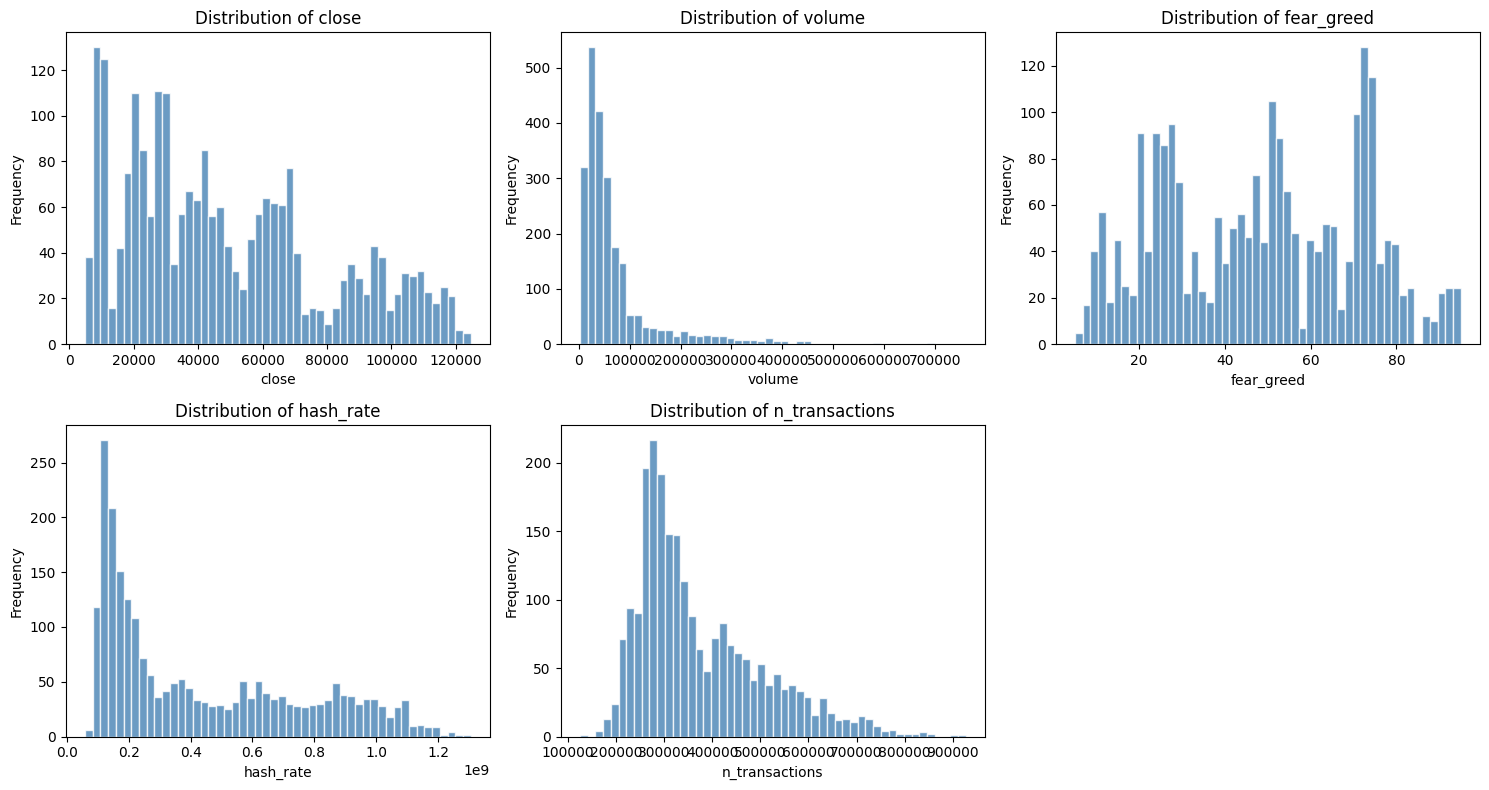

In [18]:
# Distribution 
features = ["close", "volume", "fear_greed", "hash_rate", "n_transactions"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide the last empty subplot
axes[5].axis("off")

plt.tight_layout()
plt.show()

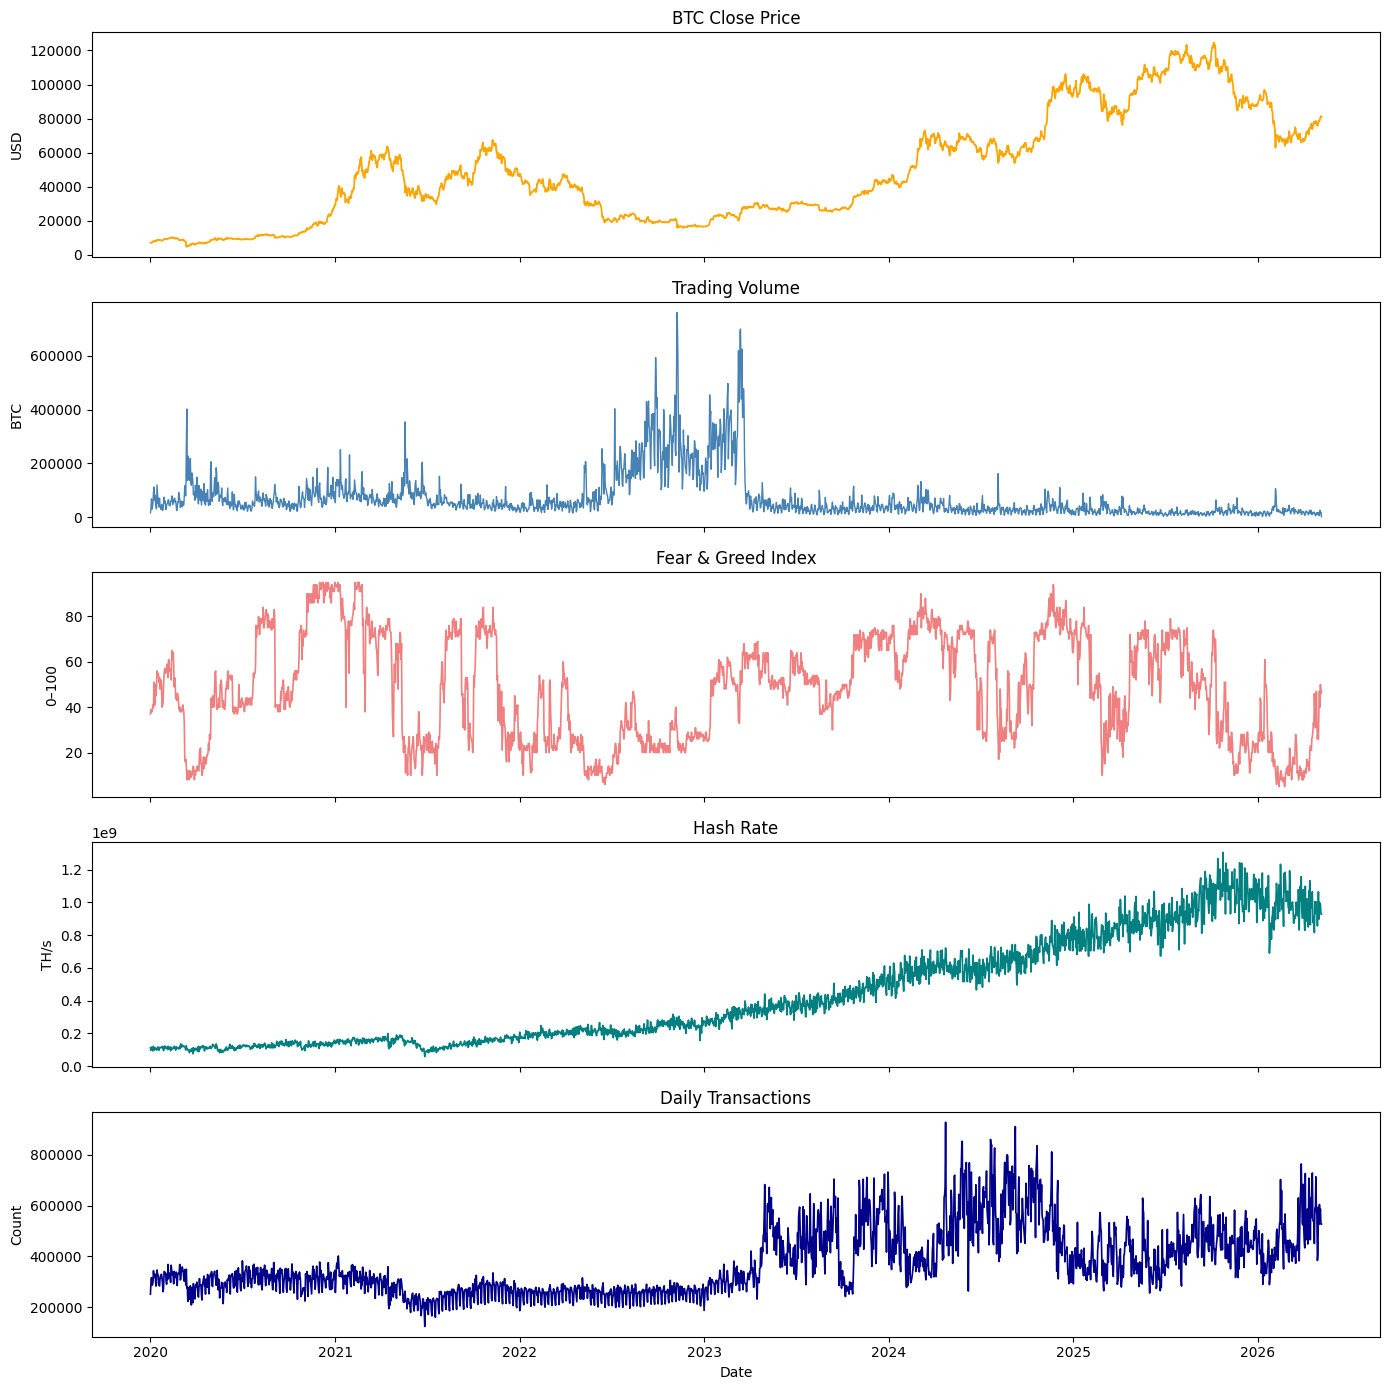

In [19]:
# Overall look of all features
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

axes[0].plot(df.index, df["close"], color="orange", linewidth=1.3)
axes[0].set_title("BTC Close Price")
axes[0].set_ylabel("USD")

axes[1].plot(df.index, df["volume"], color="steelblue", linewidth=1)
axes[1].set_title("Trading Volume")
axes[1].set_ylabel("BTC")

axes[2].plot(df.index, df["fear_greed"], color="lightcoral", linewidth=1.2)
axes[2].set_title("Fear & Greed Index")
axes[2].set_ylabel("0–100")

axes[3].plot(df.index, df["hash_rate"], color="teal", linewidth=1.2)
axes[3].set_title("Hash Rate")
axes[3].set_ylabel("TH/s")

axes[4].plot(df.index, df["n_transactions"], color="darkblue", linewidth=1.2)
axes[4].set_title("Daily Transactions")
axes[4].set_ylabel("Count")
axes[4].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [24]:
# Yearly performance breakdown
df_yearly = df.copy()
df_yearly["year"] = df_yearly.index.year

# Calculate yearly start/end price
yearly_stats = df_yearly.groupby("year")["close"].agg(
    start="first",
    end="last",
    high="max",
    low="min"
)

# Calculate gain or loss percentage 
yearly_stats["return_pct"] = ((yearly_stats["end"] / yearly_stats["start"]) - 1) * 100
yearly_stats.round(2)

,start,end,high,low,return_pct
year,,,,,
2020,7200.85,28923.63,28923.63,4800.00,301.67
2021,29331.69,46216.93,67525.83,29331.69,57.57
2022,47722.65,16542.40,47722.65,15781.29,-65.34
2023,16616.75,42283.58,44170.99,16616.75,154.46
2024,44179.55,93576.00,106133.74,39568.02,111.81
2025,94591.79,87648.22,124658.54,76322.42,-7.34
2026,88839.04,80924.22,96951.78,62909.86,-8.91


In [28]:
# Calculate return
df["daily_return"] = df["close"].pct_change()
df["log_return"] = np.log(df["close"] / df["close"].shift(1))

# Daily return summary
df[["daily_return", "log_return"]].describe().round(4)

,daily_return,log_return
count,2318.0000,2318.0000
mean,0.0016,0.0010
std,0.0321,0.0327
min,-0.3950,-0.5026
25%,-0.0129,-0.0129
50%,0.0005,0.0005
75%,0.0151,0.0150
max,0.1954,0.1784


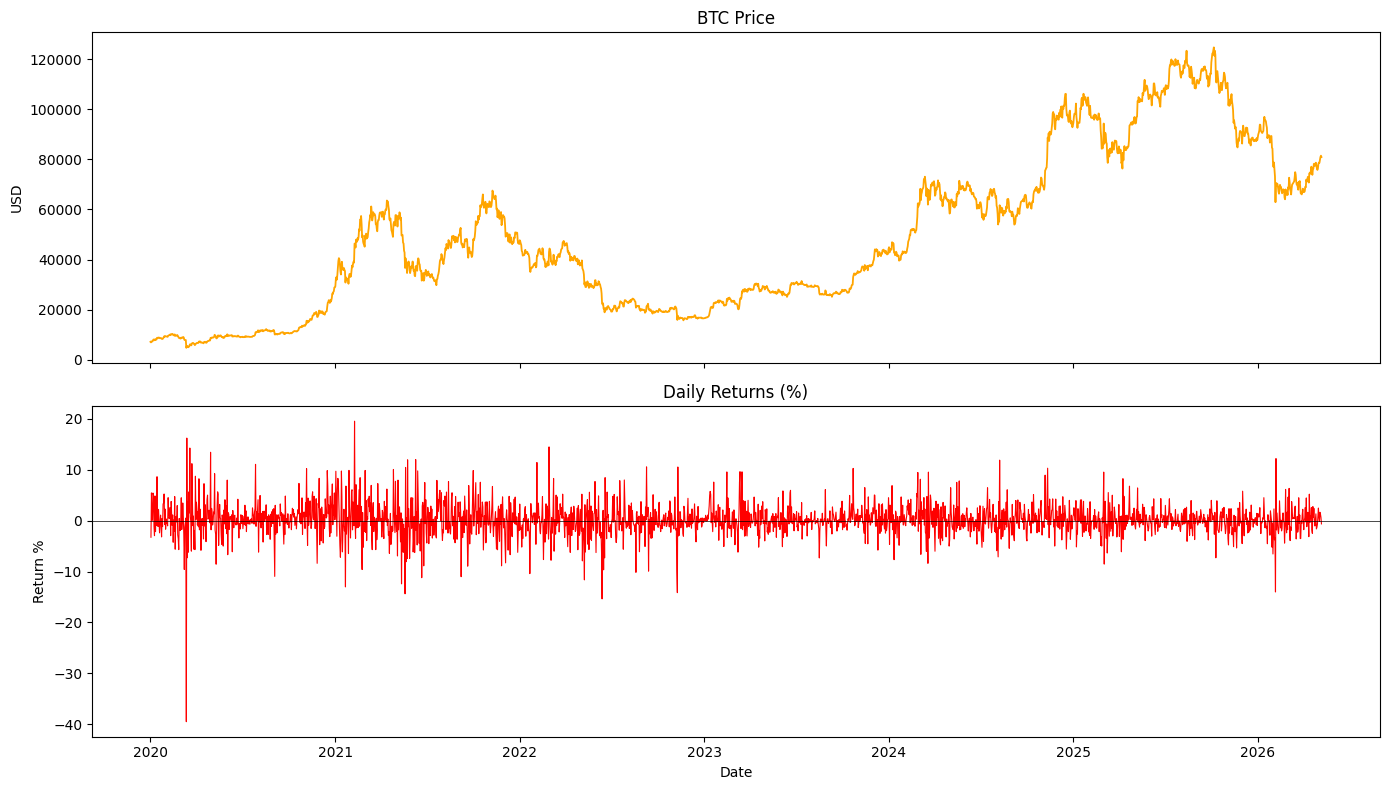

In [32]:
# Plot daily return compare with BTC price
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["close"], color="orange", linewidth=1.3)
axes[0].set_title("BTC Price")
axes[0].set_ylabel("USD")

axes[1].plot(df.index, df["daily_return"] * 100, color="red", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Daily Returns (%)")
axes[1].set_ylabel("Return %")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

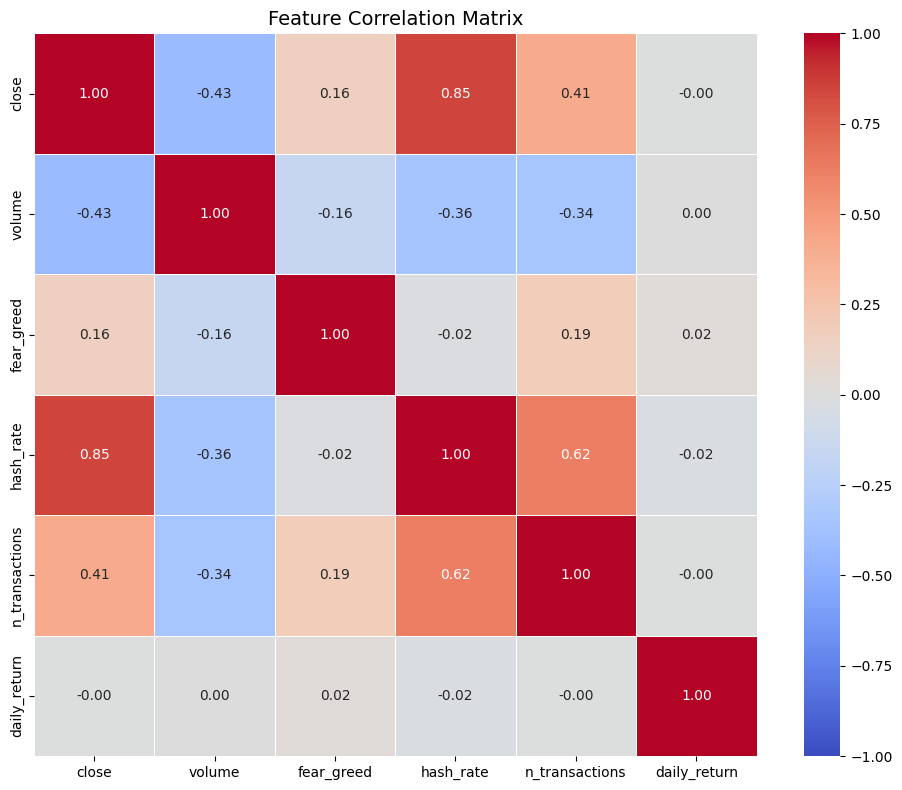

In [34]:
# Correlation matrix for corr between features

# Use both features and the target
corr_features = ["close", "volume", "fear_greed", "hash_rate", "n_transactions", "daily_return"]
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=0.5,
    square=True
)
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()